In [2]:
! pip install pyreadstat

In [3]:
import pandas as pd
import pyreadstat

# Replace 'your_file.sav' with the path to your .sav file
file_path_ABSENTEE = 'data/ABSENTEE.SAV'
file_path_BatchId = 'data/BatchId.sav'
file_path_DEATH = 'data/DEATH.SAV'
file_path_Household = 'data/Household.SAV'
file_path_Individual01 = 'data/Individual01.SAV'
file_path_Individual02 = 'data/Individual02.SAV'

Absentee, meta1 = pyreadstat.read_sav(file_path_ABSENTEE)
BatchId, meta2 = pyreadstat.read_sav(file_path_BatchId)
Death, meta3 = pyreadstat.read_sav(file_path_DEATH)
Household, meta4 = pyreadstat.read_sav(file_path_Household)
Individual01, meta5 = pyreadstat.read_sav(file_path_Individual01)
Individual02, meta6 = pyreadstat.read_sav(file_path_Individual02)

"""df1.to_csv("ABSENTEE.csv", index=False)
   df2.to_csv("BatchId.csv", index=False)
   df3.to_csv("DEATH.csv", index=False)
   df4.to_csv("Household.csv", index=False)
   df5.to_csv("Individual01.csv", index=False)
   df6.to_csv("Individual02.csv", index=False)"""

'df1.to_csv("ABSENTEE.csv", index=False)\n   df2.to_csv("BatchId.csv", index=False)\n   df3.to_csv("DEATH.csv", index=False)\n   df4.to_csv("Household.csv", index=False)\n   df5.to_csv("Individual01.csv", index=False)\n   df6.to_csv("Individual02.csv", index=False)'

In [4]:
print("BatchID")
BatchId.shape

BatchID


(3973, 9)

In [5]:
print("Columns:\n", BatchId.columns.tolist())  # Lists all column names
print("Number of columns:",len(BatchId.columns))  # Counts the number of columns


Columns:
 ['DIST', 'DNAME', 'VDCMUN', 'VNAME', 'DDVVV', 'DEV_REG', 'ECO_BELT', 'ECO_DEV', 'URB_RUR']
Number of columns: 9


# Data cleaning

In [6]:
# Handling missing values and duplicates
print("Missing Values Per Column:\n")
print(BatchId.isnull().sum())
print("\nNumber of Duplicate Rows:", BatchId.duplicated().sum())

Missing Values Per Column:

DIST        0
DNAME       0
VDCMUN      0
VNAME       0
DDVVV       0
DEV_REG     0
ECO_BELT    0
ECO_DEV     0
URB_RUR     0
dtype: int64

Number of Duplicate Rows: 0


### Extracting and Applying Metadata (Labels and Descriptions)

In [7]:
print(meta2.column_names)
print(meta2.column_labels)

['DIST', 'DNAME', 'VDCMUN', 'VNAME', 'DDVVV', 'DEV_REG', 'ECO_BELT', 'ECO_DEV', 'URB_RUR']
['District', None, 'V.D.C./Municipality', None, None, 'Development Region', 'Ecological Belt', 'Eco-Development Region', 'Urban / Rural']


In [8]:
# Get value labels for categorical variables
print(meta2.value_labels)

{'labels0': {1.0: 'Taplejung', 2.0: 'Panchthar', 3.0: 'Ilam', 4.0: 'Jhapa', 5.0: 'Morang', 6.0: 'Sunsari', 7.0: 'Dhankuta', 8.0: 'Terhathum', 9.0: 'Sankhuwasabha', 10.0: 'Bhojpur', 11.0: 'Solukhumbu', 12.0: 'Okhaldhunga', 13.0: 'Khotang', 14.0: 'Udayapur', 15.0: 'Saptari', 16.0: 'Siraha', 17.0: 'Dhanusa', 18.0: 'Mahottari', 19.0: 'Sarlahi', 20.0: 'Sindhuli', 21.0: 'Ramechhap', 22.0: 'Dolakha', 23.0: 'Sindhupalchok', 24.0: 'Kavrepalanchok', 25.0: 'Lalitpur', 26.0: 'Bhaktapur', 27.0: 'Kathmandu', 28.0: 'Nuwakot', 29.0: 'Rasuwa', 30.0: 'Dhading', 31.0: 'Makwanpur', 32.0: 'Rautahat', 33.0: 'Bara', 34.0: 'Parsa', 35.0: 'Chitawan', 36.0: 'Gorkha', 37.0: 'Lamjung', 38.0: 'Tanahu', 39.0: 'Syangja', 40.0: 'Kaski', 41.0: 'Manang', 42.0: 'Mustang', 43.0: 'Myagdi', 44.0: 'Parbat', 45.0: 'Baglung', 46.0: 'Gulmi', 47.0: 'Palpa', 48.0: 'Nawalparasi', 49.0: 'Rupandehi', 50.0: 'Kapilbastu', 51.0: 'Arghakhanchi', 52.0: 'Pyuthan', 53.0: 'Rolpa', 54.0: 'Rukum', 55.0: 'Salyan', 56.0: 'Dang', 57.0: 'Banke',

### Rename columns in the DataFrame using metadata

In [9]:
col_names = ['DIST', 'DNAME', 'VDCMUN', 'VNAME', 'DDVVV', 'DEV_REG', 'ECO_BELT', 'ECO_DEV', 'URB_RUR']
col_labels = ['District', 'District Name', 'V.D.C./Municipality', 'V.D.C./Municipality Name', 'Combined Code', 'Development Region', 'Ecological Belt', 'Eco-Development Region', 'Urban / Rural']

rename_dict = dict(zip(col_names, col_labels))

BatchId.rename(columns=rename_dict, inplace=True)

print(BatchId.columns)


Index(['District', 'District Name', 'V.D.C./Municipality',
       'V.D.C./Municipality Name', 'Combined Code', 'Development Region',
       'Ecological Belt', 'Eco-Development Region', 'Urban / Rural'],
      dtype='object')


In [10]:
BatchId.head()

,District,District Name,V.D.C./Municipality,V.D.C./Municipality Name,Combined Code,Development Region,Ecological Belt,Eco-Development Region,Urban / Rural
0,1.0,Taplejung,1.0,Ambegudin,1001.0,1.0,1.0,11.0,2.0
1,1.0,Taplejung,2.0,Angkhop,1002.0,1.0,1.0,11.0,2.0
2,1.0,Taplejung,3.0,Chaksibote,1003.0,1.0,1.0,11.0,2.0
3,1.0,Taplejung,4.0,Change,1004.0,1.0,1.0,11.0,2.0
4,1.0,Taplejung,5.0,Dhungesanghu,1005.0,1.0,1.0,11.0,2.0


In [11]:
print(BatchId.dtypes)


District                    float64
District Name                object
V.D.C./Municipality         float64
V.D.C./Municipality Name     object
Combined Code               float64
Development Region          float64
Ecological Belt             float64
Eco-Development Region      float64
Urban / Rural               float64
dtype: object


In [12]:
# Mapping dictionary: key = label key in metadata, value = column name in DataFrame
label_to_column = {
        'labels2': 'Development Region',
        'labels3':'Ecological Belt',
        'labels4': 'Eco-Development Region',
        'labels5': 'Urban / Rural',
}

for label_key, col_name in label_to_column.items():
    if label_key in meta2.value_labels:
        BatchId[col_name] = BatchId[col_name].map(meta2.value_labels[label_key])


In [13]:
BatchId.head()

,District,District Name,V.D.C./Municipality,V.D.C./Municipality Name,Combined Code,Development Region,Ecological Belt,Eco-Development Region,Urban / Rural
0,1.0,Taplejung,1.0,Ambegudin,1001.0,Easter Dev. Region,Mountain,Eastern Mountain,Rural
1,1.0,Taplejung,2.0,Angkhop,1002.0,Easter Dev. Region,Mountain,Eastern Mountain,Rural
2,1.0,Taplejung,3.0,Chaksibote,1003.0,Easter Dev. Region,Mountain,Eastern Mountain,Rural
3,1.0,Taplejung,4.0,Change,1004.0,Easter Dev. Region,Mountain,Eastern Mountain,Rural
4,1.0,Taplejung,5.0,Dhungesanghu,1005.0,Easter Dev. Region,Mountain,Eastern Mountain,Rural


# Descriptive Analysis

### VDCs/Municipalities Overview
How many VDCs/Municipalities in each district?

How many Urban and Rural VDCs/Municipalities in each district?

Total number of VDCs/Municipalities in the country

Total number of Urban and Rural across the country

How many VDCs/Municipalities in each district?


In [14]:
# Count unique VDCs/Municipalities in each District
vdc_per_district = BatchId.groupby('District Name')['V.D.C./Municipality Name'].nunique().sort_values(ascending=False)

# Display the result
print("Number of VDCs/Municipalities in each District:")
print(vdc_per_district)


Number of VDCs/Municipalities in each District:
District Name
Saptari       115
Siraha        108
Dhanusa       102
Sarlahi       100
Bara           99
             ... 
Kanchanpur     20
Rasuwa         18
Bhaktapur      18
Mustang        16
Manang         13
Name: V.D.C./Municipality Name, Length: 75, dtype: int64


How many Urban and Rural VDCs/Municipalities in each district?


C:\Users\sagun\AppData\Local\Temp\ipykernel_6384\737776232.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vdc_per_district.values, y=vdc_per_district.index, palette="viridis")


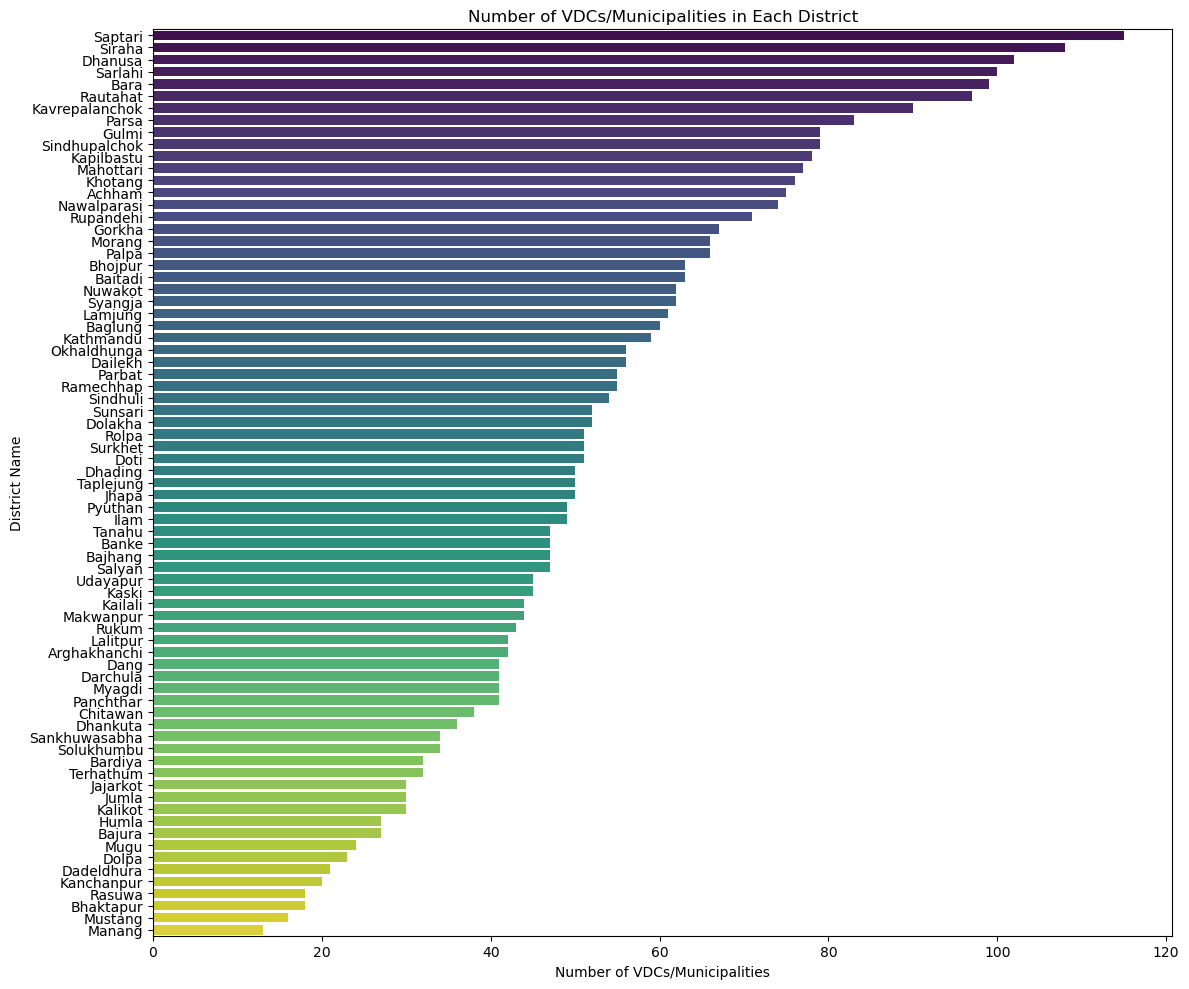

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting the VDCs/Municipalities per district
plt.figure(figsize=(12, 10))
sns.barplot(x=vdc_per_district.values, y=vdc_per_district.index, palette="viridis")

plt.title("Number of VDCs/Municipalities in Each District")
plt.xlabel("Number of VDCs/Municipalities")
plt.ylabel("District Name")
plt.tight_layout()
plt.show()


Urban and Rural VDCs/Municipalities in each District:
Urban / Rural  Rural  Urban
District Name              
Achham            75      0
Arghakhanchi      42      0
Baglung           59      1
Baitadi           62      1
Bajhang           47      0
...              ...    ...
Syangja           60      2
Tanahu            46      1
Taplejung         50      0
Terhathum         32      0
Udayapur          44      1

[75 rows x 2 columns]


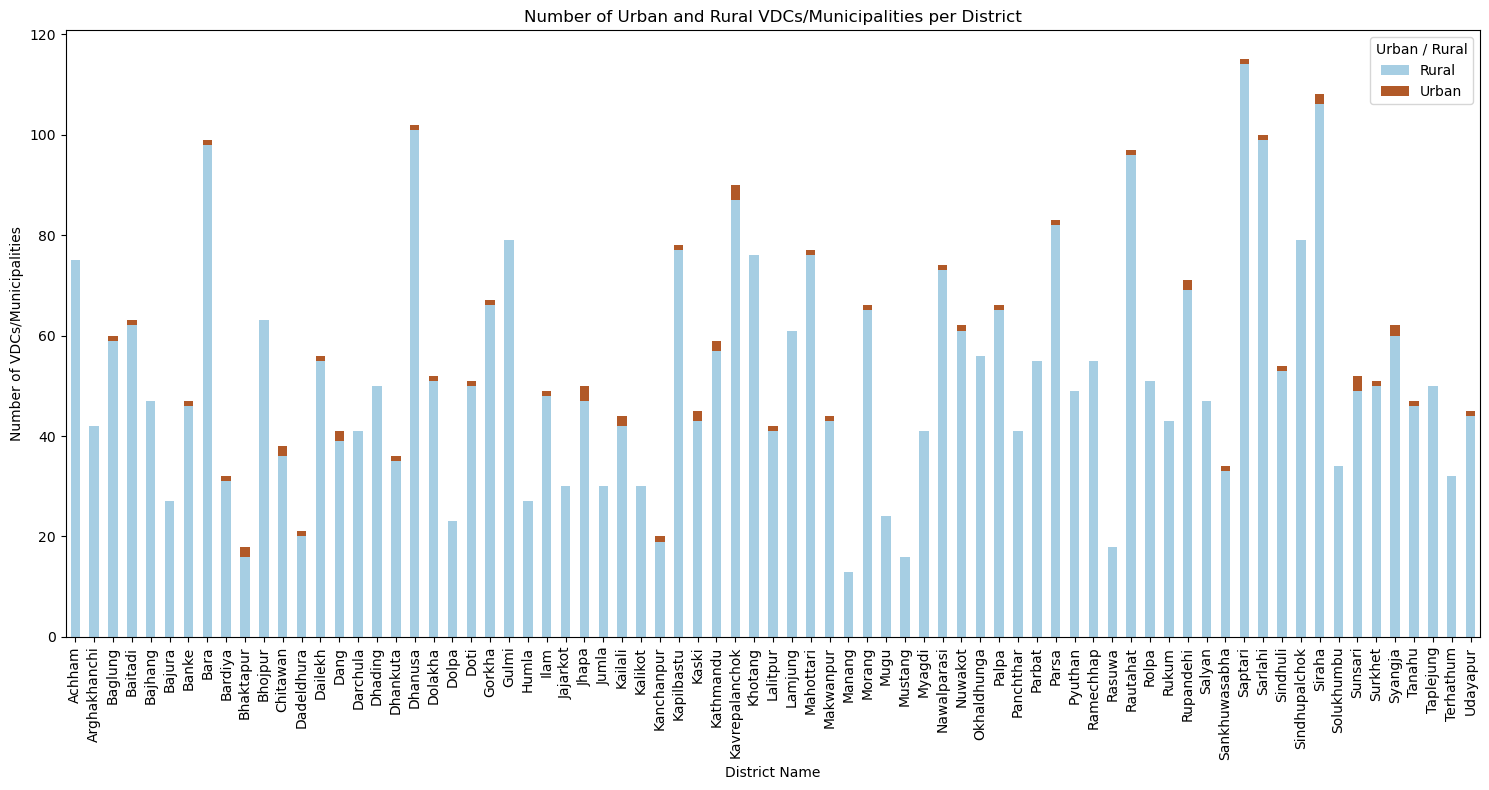

In [16]:
# Group by District and Urban/Rural column, then count VDCs
urban_rural_counts = BatchId.groupby(['District Name', 'Urban / Rural'])['V.D.C./Municipality Name'].nunique().unstack().fillna(0).astype(int)

# Display the result
print("Urban and Rural VDCs/Municipalities in each District:")
print(urban_rural_counts)

import matplotlib.pyplot as plt

# Plot stacked bar chart
urban_rural_counts.plot(kind='bar', stacked=True, figsize=(15,8), colormap='Paired')

plt.title('Number of Urban and Rural VDCs/Municipalities per District')
plt.xlabel('District Name')
plt.ylabel('Number of VDCs/Municipalities')
plt.xticks(rotation=90)
plt.legend(title='Urban / Rural', loc='upper right')
plt.tight_layout()
plt.show()



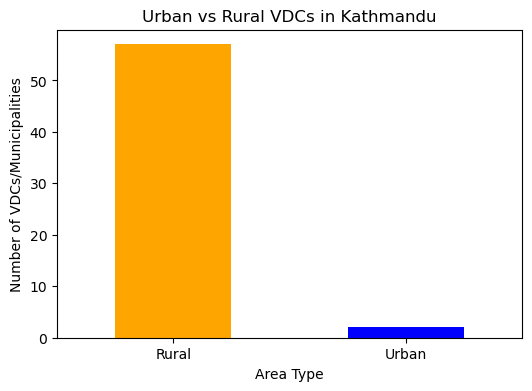

In [17]:
# Filter data for Kathmandu only
kathmandu_urban_rural = urban_rural_counts.loc['Kathmandu']

# Plot
kathmandu_urban_rural.plot(kind='bar', color=['orange', 'blue'], figsize=(6,4))

plt.title('Urban vs Rural VDCs in Kathmandu')
plt.xlabel('Area Type')
plt.ylabel('Number of VDCs/Municipalities')
plt.xticks(rotation=0)
plt.show()


Total number of VDCs/Municipalities in the country


Total number of VDCs/Municipalities in Nepal: 3696


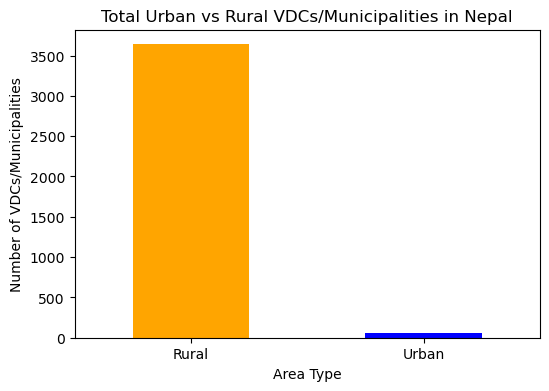

In [18]:
total_vdcs = BatchId['V.D.C./Municipality Name'].nunique()
print(f"Total number of VDCs/Municipalities in Nepal: {total_vdcs}")
# Count total Urban and Rural VDCs
total_urban_rural = BatchId.groupby('Urban / Rural')['V.D.C./Municipality Name'].nunique()

# Plot bar chart
total_urban_rural.plot(kind='bar', color=['orange', 'blue'], figsize=(6,4))

plt.title('Total Urban vs Rural VDCs/Municipalities in Nepal')
plt.xlabel('Area Type')
plt.ylabel('Number of VDCs/Municipalities')
plt.xticks(rotation=0)
plt.show()


###  Ecological Belt Analysis
How many unique ecological belts are there?

How many districts fall under each ecological belt?

 Find unique ecological belts

In [19]:
unique_ecobelts = BatchId['Ecological Belt'].unique()
print(f"Number of unique ecological belts: {len(unique_ecobelts)}")
print("Ecological Belts:", unique_ecobelts)


Number of unique ecological belts: 3
Ecological Belts: ['Mountain' 'Hill' 'Terai']


Count how many districts fall under each ecological belt

In [20]:
# Get unique district-ecobelt pairs
district_ecobelt = BatchId[['District Name', 'Ecological Belt']].drop_duplicates()

# Count districts per ecological belt
districts_per_ecobelt = district_ecobelt.groupby('Ecological Belt')['District Name'].nunique().sort_values(ascending=False)
print(districts_per_ecobelt)


Ecological Belt
Hill        39
Terai       20
Mountain    16
Name: District Name, dtype: int64


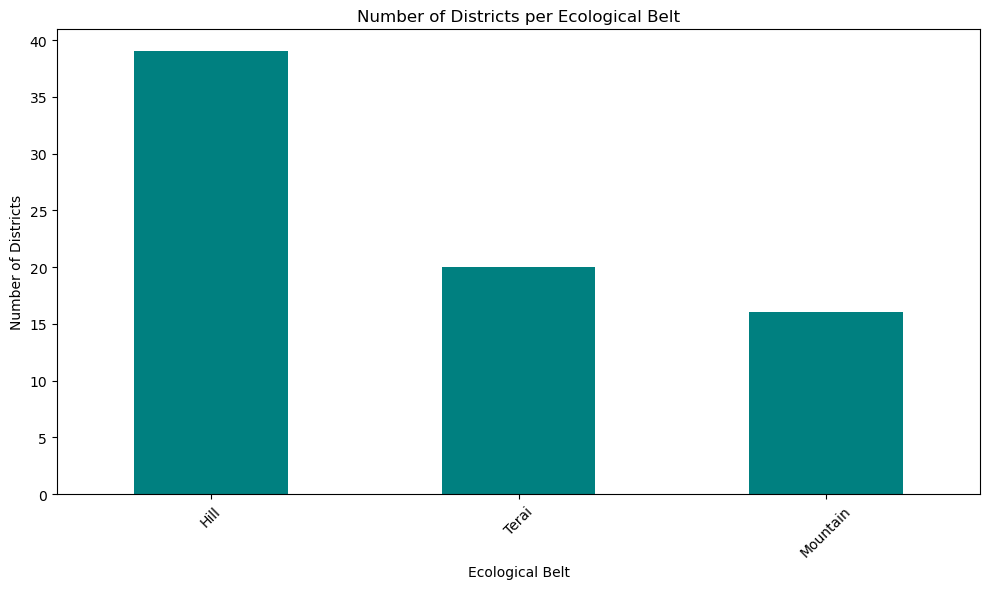

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
districts_per_ecobelt.plot(kind='bar', color='teal')
plt.title('Number of Districts per Ecological Belt')
plt.xlabel('Ecological Belt')
plt.ylabel('Number of Districts')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Eco-Development Region Analysis
How many unique Eco-Development Regions are there?

How many districts are in each Eco-Development Region?

How many Urban and Rural VDCs/Municipalities fall in each Eco-Development Region?



 How many unique Eco-Development Regions and what are they?

In [22]:
unique_eco_dev_regions = BatchId['Eco-Development Region'].unique()
print(f"Number of unique Eco-Development Regions: {len(unique_eco_dev_regions)}")
print("Eco-Development Regions:", unique_eco_dev_regions)


Number of unique Eco-Development Regions: 15
Eco-Development Regions: ['Eastern Mountain' 'Eastern Hill' 'Eastern Terai' 'Central Terai'
 'Central Hill' 'Central Mountain' 'Western Hill' 'Western Mountain'
 'Western Terai' 'Mid-Western Hill' 'Mid-Western Terai'
 'Mid-Western Mountain' 'Far-Western Mountain' 'Far-Western Hill'
 'Far-Western Terai']


How many districts are in each Eco-Development Region, and which districts?

Number of districts in each Eco-Development Region:
Eco-Development Region
Western Hill            11
Central Hill             9
Eastern Hill             8
Central Terai            7
Mid-Western Hill         7
Eastern Terai            5
Mid-Western Mountain     5
Far-Western Hill         4
Central Mountain         3
Eastern Mountain         3
Far-Western Mountain     3
Mid-Western Terai        3
Western Terai            3
Far-Western Terai        2
Western Mountain         2
Name: District Name, dtype: int64

Districts in each Eco-Development Region:
Eco-Development Region
Central Hill            [Sindhuli, Ramechhap, Kavrepalanchok, Lalitpur...
Central Mountain                         [Dolakha, Sindhupalchok, Rasuwa]
Central Terai           [Dhanusa, Mahottari, Sarlahi, Rautahat, Bara, ...
Eastern Hill            [Panchthar, Ilam, Dhankuta, Terhathum, Bhojpur...
Eastern Mountain                   [Taplejung, Sankhuwasabha, Solukhumbu]
Eastern Terai                   [Jhapa, Morang, Su

C:\Users\sagun\AppData\Local\Temp\ipykernel_6384\800141026.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=districts_per_eco_dev.index, y=districts_per_eco_dev.values, palette='viridis')


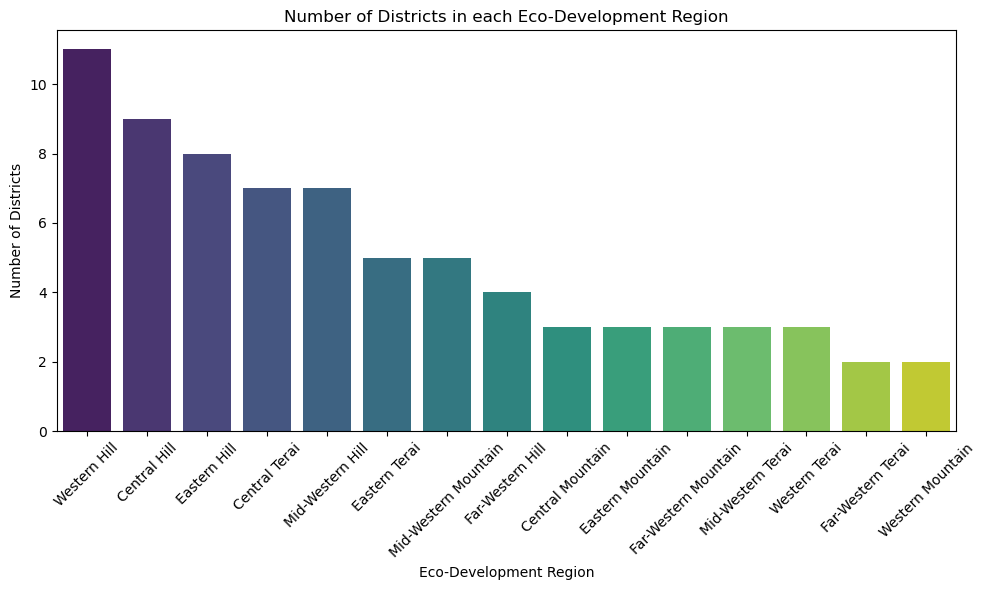

In [23]:
# Get unique district and eco-development region pairs
district_eco_dev = BatchId[['District Name', 'Eco-Development Region']].drop_duplicates()

# Count districts per eco-development region
districts_per_eco_dev = district_eco_dev.groupby('Eco-Development Region')['District Name'].nunique().sort_values(ascending=False)
print("Number of districts in each Eco-Development Region:")
print(districts_per_eco_dev)

# List districts per eco-development region
districts_list_per_eco_dev = district_eco_dev.groupby('Eco-Development Region')['District Name'].apply(list)
print("\nDistricts in each Eco-Development Region:")
print(districts_list_per_eco_dev)

# Visualization
plt.figure(figsize=(10,6))
sns.barplot(x=districts_per_eco_dev.index, y=districts_per_eco_dev.values, palette='viridis')
plt.title('Number of Districts in each Eco-Development Region')
plt.xlabel('Eco-Development Region')
plt.ylabel('Number of Districts')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


 How many Urban and Rural VDCs/Municipalities fall in each Eco-Development Region?

Urban / Rural           Rural  Urban
Eco-Development Region              
Central Hill              457     11
Central Mountain          146      1
Central Terai             563      8
Eastern Hill              390      3
Eastern Mountain          117      1
Eastern Terai             373     10
Far-Western Hill          204      3
Far-Western Mountain      114      0
Far-Western Terai          60      3
Mid-Western Hill          319      2
Mid-Western Mountain      133      0
Mid-Western Terai         115      4
Western Hill              600      8
Western Mountain           29      0
Western Terai             215      4


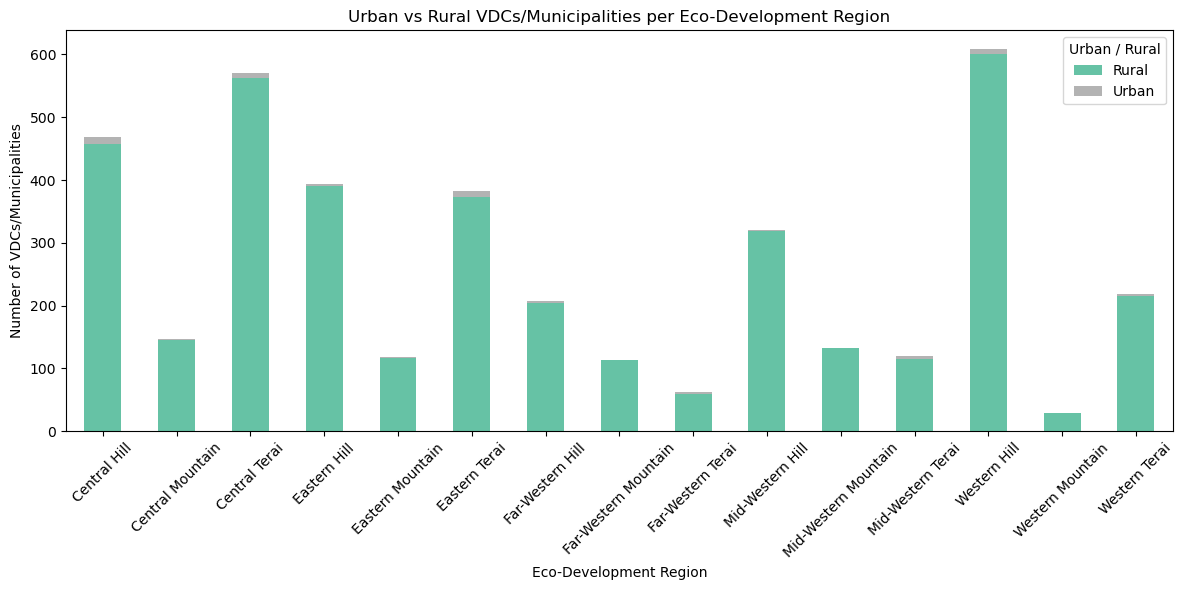

In [24]:
urban_rural_eco_dev = BatchId.groupby(['Eco-Development Region', 'Urban / Rural'])['V.D.C./Municipality Name'].nunique().unstack(fill_value=0)
print(urban_rural_eco_dev)
urban_rural_eco_dev.plot(kind='bar', stacked=True, figsize=(12,6), colormap='Set2')
plt.title('Urban vs Rural VDCs/Municipalities per Eco-Development Region')
plt.xlabel('Eco-Development Region')
plt.ylabel('Number of VDCs/Municipalities')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
